In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [3]:
df = pd.read_csv("data/raw/training_data.csv")

print("Shape:", df.shape)
df.head()

Shape: (48000, 14)


,event_type,version,timestamp,machine_id,sensor_id,temperature,vibration,pressure,rotation_speed,load,ambient_temperature,operating_mode,rul_hours,scenario
0,sensor_reading,1.0,2025-01-01 00:00:00,M001,MAIN_SENSOR,624.862,0.0342,24.102,1641.49,0.600,30.00,normal,9999.0,normal
1,sensor_reading,1.0,2025-01-01 00:05:00,M001,MAIN_SENSOR,625.678,0.0331,23.525,1638.58,0.601,30.01,high-load,9999.0,normal
2,sensor_reading,1.0,2025-01-01 00:10:00,M001,MAIN_SENSOR,629.657,0.0343,24.007,1635.29,0.601,30.01,normal,9999.0,normal
3,sensor_reading,1.0,2025-01-01 00:15:00,M001,MAIN_SENSOR,632.964,0.0323,24.058,1617.44,0.602,30.02,normal,9999.0,normal
4,sensor_reading,1.0,2025-01-01 00:20:00,M001,MAIN_SENSOR,625.596,0.0333,24.399,1627.55,0.603,30.02,idle,9999.0,normal


In [5]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")
df.describe()

,version,timestamp,temperature,vibration,pressure,rotation_speed,load,ambient_temperature,rul_hours
count,48000.0,48000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000
mean,1.0,2025-02-03 20:27:30,983.855683,0.122639,22.395484,1593.475271,0.600000,30.000000,1996.702865
min,1.0,2025-01-01 00:00:00,586.621000,0.017900,3.919000,1093.470000,0.300000,25.000000,0.000000
25%,1.0,2025-01-14 21:18:45,631.865750,0.038700,21.228000,1545.947500,0.388000,26.460000,475.060000
50%,1.0,2025-02-01 05:57:30,650.692000,0.054300,23.342000,1611.770000,0.600000,30.000000,1000.040000
75%,1.0,2025-02-22 01:56:15,695.780500,0.165800,24.851000,1676.960000,0.812000,33.540000,1500.020000
max,1.0,2025-03-25 07:55:00,5722.811000,0.731500,35.804000,2123.070000,0.900000,35.000000,9999.000000
std,0.0,NaN,1001.337877,0.127948,3.509893,106.884196,0.212132,3.535495,3073.563878


In [6]:
df["temp_roll_mean"] = df["temperature"].rolling(window=10).mean()
df["vib_roll_mean"] = df["vibration"].rolling(window=10).mean()
df["press_roll_mean"] = df["pressure"].rolling(window=10).mean()
df["rpm_roll_mean"] = df["rotation_speed"].rolling(window=10).mean()

In [7]:
df["temp_roll_std"] = df["temperature"].rolling(window=10).std()
df["vib_roll_std"] = df["vibration"].rolling(window=10).std()
df["press_roll_std"] = df["pressure"].rolling(window=10).std()
df["rpm_roll_std"] = df["rotation_speed"].rolling(window=10).std()

In [8]:
df["temp_roc"] = df["temperature"].diff()
df["vib_roc"] = df["vibration"].diff()
df["press_roc"] = df["pressure"].diff()
df["rpm_roc"] = df["rotation_speed"].diff()

In [9]:
df = df.dropna()

In [10]:
df

,event_type,version,timestamp,machine_id,sensor_id,temperature,vibration,pressure,rotation_speed,load,...,press_roll_mean,rpm_roll_mean,temp_roll_std,vib_roll_std,press_roll_std,rpm_roll_std,temp_roc,vib_roc,press_roc,rpm_roc
30003,sensor_reading,1.0,2025-01-01 00:15:00,M003,MAIN_SENSOR,628.050,0.0330,24.003,1630.16,0.601,...,23.9214,1634.227,3.215227,0.001515,0.182178,5.882390,-1.607,-0.0013,-0.004,-5.13
6003,sensor_reading,1.0,2025-01-01 00:15:00,M002,MAIN_SENSOR,629.775,0.0304,23.267,1637.94,0.600,...,23.8379,1633.872,2.992053,0.001776,0.263439,5.489359,1.725,-0.0026,-0.736,7.78
3,sensor_reading,1.0,2025-01-01 00:15:00,M001,MAIN_SENSOR,632.964,0.0323,24.058,1617.44,0.602,...,23.8671,1631.872,2.779036,0.001765,0.270668,7.367176,3.189,0.0019,0.791,-20.50
30004,sensor_reading,1.0,2025-01-01 00:20:00,M003,MAIN_SENSOR,628.067,0.0330,24.004,1630.21,0.601,...,23.8675,1631.893,2.777195,0.001765,0.270889,7.361544,-4.897,0.0007,-0.054,12.77
4,sensor_reading,1.0,2025-01-01 00:20:00,M001,MAIN_SENSOR,625.596,0.0333,24.399,1627.55,0.603,...,23.9330,1630.298,2.510526,0.001012,0.313540,6.204210,-2.471,0.0003,0.395,-2.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,sensor_reading,1.0,2025-03-25 07:35:00,M002,MAIN_SENSOR,741.065,0.2420,19.247,1294.17,0.599,...,24.0345,1563.778,29.592156,0.023543,6.746755,161.767363,62.991,-0.0207,-15.868,-331.45
29996,sensor_reading,1.0,2025-03-25 07:40:00,M002,MAIN_SENSOR,756.586,0.2678,18.301,1666.61,0.600,...,24.6142,1586.939,31.084335,0.022183,5.833128,157.812985,15.521,0.0258,-0.946,372.44
29997,sensor_reading,1.0,2025-03-25 07:45:00,M002,MAIN_SENSOR,714.503,0.2729,11.713,1532.30,0.600,...,23.3766,1580.123,30.727044,0.019980,7.126453,158.633914,-42.083,0.0051,-6.588,-134.31
29998,sensor_reading,1.0,2025-03-25 07:50:00,M002,MAIN_SENSOR,743.029,0.2129,20.255,1735.59,0.600,...,22.8559,1596.378,31.067004,0.024677,7.147348,165.985286,28.526,-0.0600,8.542,203.29


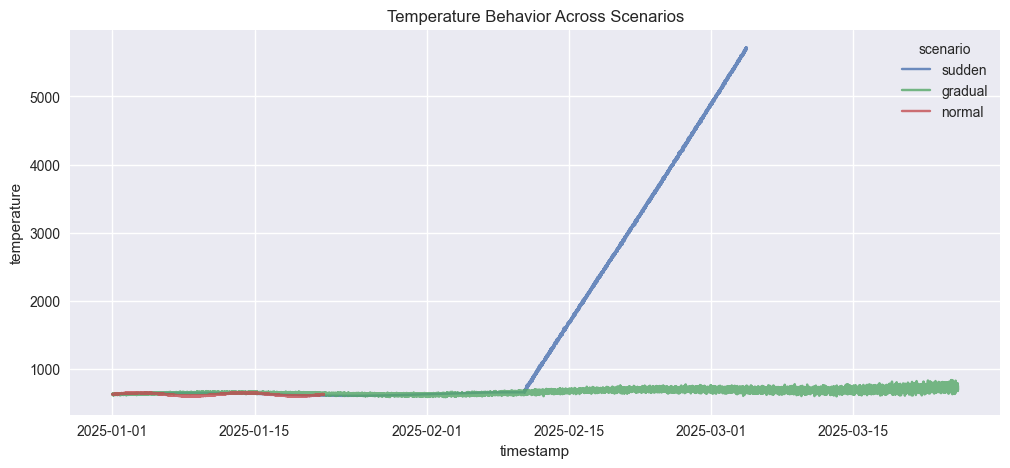

In [11]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=df,
    x="timestamp",
    y="temperature",
    hue="scenario",
    alpha=0.8
)

plt.title("Temperature Behavior Across Scenarios")
plt.show()

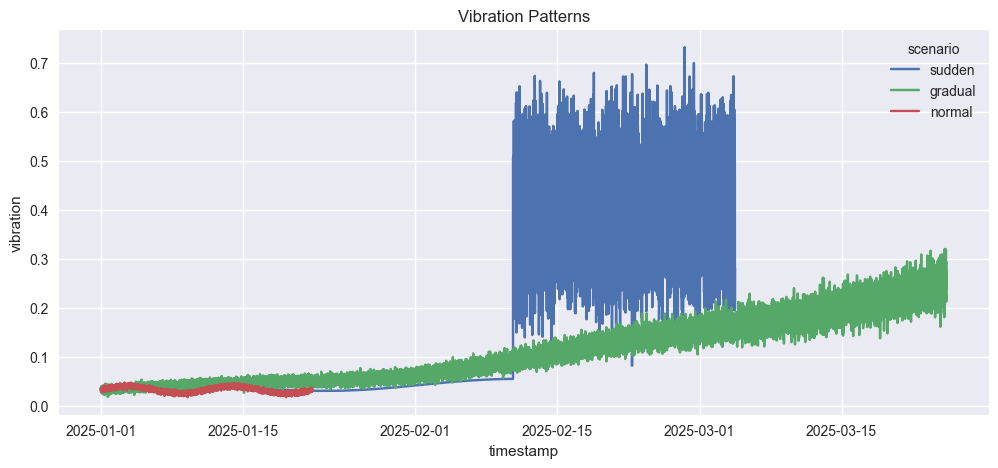

In [12]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=df,
    x="timestamp",
    y="vibration",
    hue="scenario"
)

plt.title("Vibration Patterns")
plt.show()

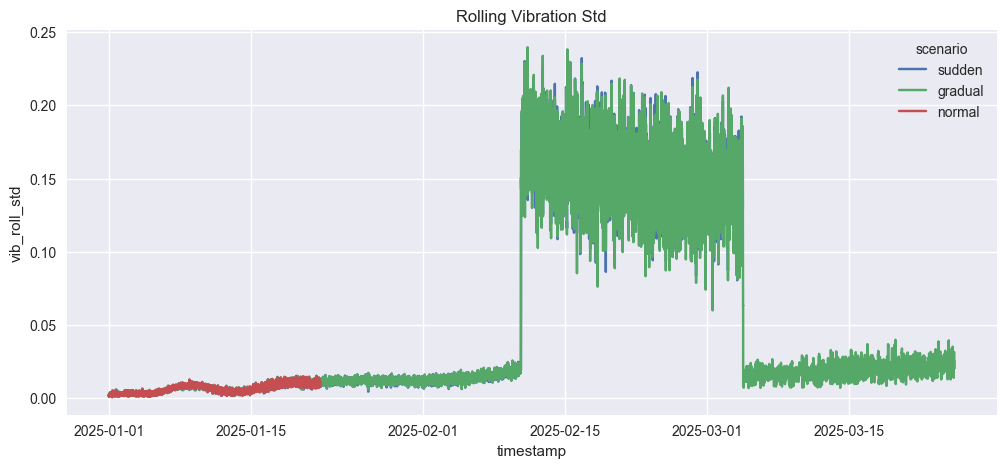

In [13]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=df,
    x="timestamp",
    y="vib_roll_std",
    hue="scenario"
)

plt.title("Rolling Vibration Std")
plt.show()

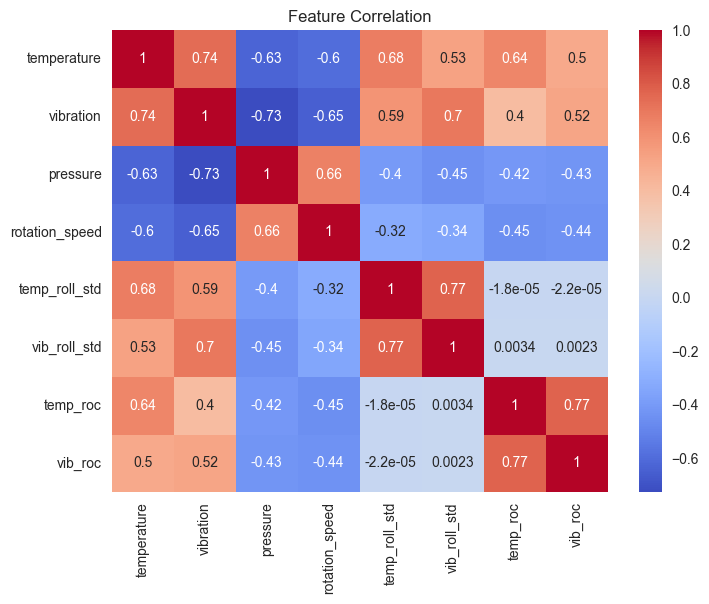

In [14]:
features = [
    "temperature",
    "vibration",
    "pressure",
    "rotation_speed",
    "temp_roll_std",
    "vib_roll_std",
    "temp_roc",
    "vib_roc"
]

corr = df[features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [15]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [16]:
features = [
    "temperature",
    "vibration",
    "pressure",
    "rotation_speed",
    "temp_roll_std",
    "vib_roll_std",
    "temp_roc",
    "vib_roc"
]

X = df[features]

In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [18]:
model = IsolationForest(
    contamination=0.05,
    n_estimators=200,
    random_state=42
)

model.fit(X_scaled)

IsolationForest(contamination=0.05, n_estimators=200, random_state=42)

In [19]:
df["anomaly_pred_005"] = model.predict(X_scaled)
df["anomaly_pred_005"] = df["anomaly_pred_005"].map({1:0, -1:1})

In [20]:
contamination_values = [0.05, 0.1, 0.15]

for c in contamination_values:
    
    model = IsolationForest(
        contamination=c,
        n_estimators=200,
        random_state=42
    )
    
    preds = model.fit_predict(X_scaled)
    
    preds = pd.Series(preds).map({1:0, -1:1})
    
    df[f"anomaly_pred_{int(c*100)}"] = preds

In [22]:
df[[
    "anomaly_pred_5",
    "anomaly_pred_10",
    "anomaly_pred_15"
]].sum()

anomaly_pred_5     2400.0
anomaly_pred_10    4798.0
anomaly_pred_15    7198.0
dtype: float64

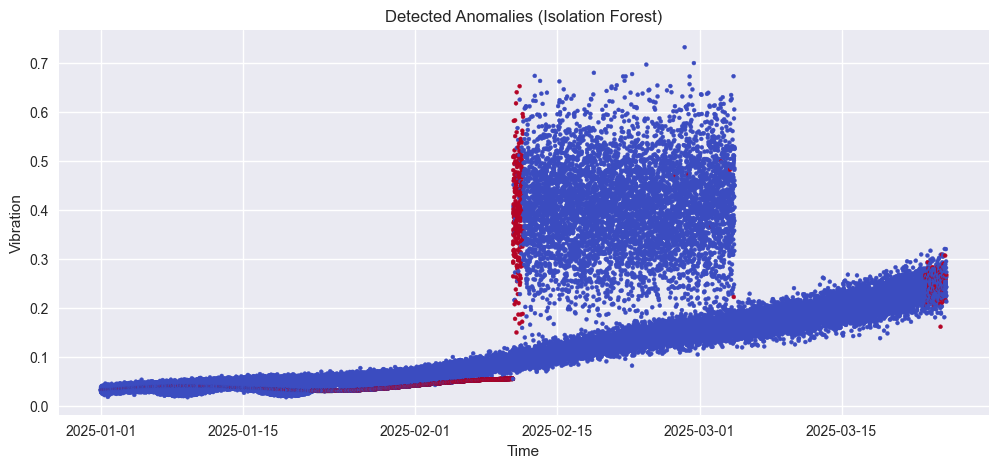

In [23]:
plt.figure(figsize=(12,5))

plt.scatter(
    df["timestamp"],
    df["vibration"],
    c=df["anomaly_pred_10"],
    cmap="coolwarm",
    s=8
)

plt.title("Detected Anomalies (Isolation Forest)")
plt.xlabel("Time")
plt.ylabel("Vibration")

plt.show()

In [24]:
pd.crosstab(df["scenario"], df["anomaly_pred_10"])

anomaly_pred_10,0.0,1.0
scenario,,
gradual,23895,102
normal,5997,0
sudden,13292,4696
